In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('sample_data_cleaning_project - Sample_data_cleaning_project.csv')
df

,Name,Age,Salary,Join_Date,Department
0,Pam,25.0,70200.0,1/15/2023,HR
1,Jane,NaN,65000.0,8/1/2022,Finance
2,Alice,22.0,71350.0,5/20/2021,HR
3,Bob,22.0,NaN,1/15/2023,IT
4,Pam,25.0,71250.0,1/15/2023,HR
5,Jade,40.0,NaN,1/15/2023,Finance
6,Joanne,25.0,120000.0,1/16/2023,IT
7,Kim,33.0,71568.0,8/30/2021,HR
8,Sam,40.0,NaN,9/5/2022,IT
9,Eli,NaN,80100.0,3/4/2022,HR


In [3]:
print("Missing values :")
df.isnull().sum()

Missing values :


Name          0
Age           4
Salary        7
Join_Date     0
Department    0
dtype: int64

In [4]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Salary'] = df['Salary'].fillna(df['Salary'].mean())

In [5]:
df

,Name,Age,Salary,Join_Date,Department
0,Pam,25.0,70200.000000,1/15/2023,HR
1,Jane,36.0,65000.000000,8/1/2022,Finance
2,Alice,22.0,71350.000000,5/20/2021,HR
3,Bob,22.0,132729.694444,1/15/2023,IT
4,Pam,25.0,71250.000000,1/15/2023,HR
5,Jade,40.0,132729.694444,1/15/2023,Finance
6,Joanne,25.0,120000.000000,1/16/2023,IT
7,Kim,33.0,71568.000000,8/30/2021,HR
8,Sam,40.0,132729.694444,9/5/2022,IT
9,Eli,36.0,80100.000000,3/4/2022,HR


In [6]:
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

In [7]:
df = df.apply(lambda x: x.str.lower() if x.dtype == "object" else x)
df

,Name,Age,Salary,Join_Date,Department
0,pam,25.0,70200.000000,1/15/2023,hr
1,jane,36.0,65000.000000,8/1/2022,finance
2,alice,22.0,71350.000000,5/20/2021,hr
3,bob,22.0,132729.694444,1/15/2023,it
4,pam,25.0,71250.000000,1/15/2023,hr
5,jade,40.0,132729.694444,1/15/2023,finance
6,joanne,25.0,120000.000000,1/16/2023,it
7,kim,33.0,71568.000000,8/30/2021,hr
8,sam,40.0,132729.694444,9/5/2022,it
9,eli,36.0,80100.000000,3/4/2022,hr


In [8]:
df = df.drop_duplicates(subset = ['Name', 'Age'])
df

,Name,Age,Salary,Join_Date,Department
0,pam,25.0,70200.000000,1/15/2023,hr
1,jane,36.0,65000.000000,8/1/2022,finance
2,alice,22.0,71350.000000,5/20/2021,hr
3,bob,22.0,132729.694444,1/15/2023,it
5,jade,40.0,132729.694444,1/15/2023,finance
6,joanne,25.0,120000.000000,1/16/2023,it
7,kim,33.0,71568.000000,8/30/2021,hr
8,sam,40.0,132729.694444,9/5/2022,it
9,eli,36.0,80100.000000,3/4/2022,hr
10,joe,22.0,62000.000000,10/9/2022,finance


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
q1 = df['Salary'].quantile(0.25)
q3 = df['Salary'].quantile(0.75)

IQR = q3 - q1
df = df[(df['Salary'] >= q1-1.5*IQR) & (df['Salary'] <= q3+1.5*IQR)]

In [11]:
df['Join_Date'] = pd.to_datetime(df['Join_Date'])
df

C:\Users\Admin\AppData\Local\Temp\ipykernel_18904\1037076345.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Join_Date'] = pd.to_datetime(df['Join_Date'])


,Name,Age,Salary,Join_Date,Department
0,pam,25.0,70200.000000,2023-01-15,hr
1,jane,36.0,65000.000000,2022-08-01,finance
2,alice,22.0,71350.000000,2021-05-20,hr
3,bob,22.0,132729.694444,2023-01-15,it
5,jade,40.0,132729.694444,2023-01-15,finance
6,joanne,25.0,120000.000000,2023-01-16,it
7,kim,33.0,71568.000000,2021-08-30,hr
8,sam,40.0,132729.694444,2022-09-05,it
9,eli,36.0,80100.000000,2022-03-04,hr
10,joe,22.0,62000.000000,2022-10-09,finance


In [12]:
df = pd.get_dummies(df, columns=['Department'], drop_first=True)

binary_columns = [col for col in df.columns if col.startswith('Department_')]
df[binary_columns] = df[binary_columns].astype(int)
df

,Name,Age,Salary,Join_Date,Department_hr,Department_it
0,pam,25.0,70200.000000,2023-01-15,1,0
1,jane,36.0,65000.000000,2022-08-01,0,0
2,alice,22.0,71350.000000,2021-05-20,1,0
3,bob,22.0,132729.694444,2023-01-15,0,1
5,jade,40.0,132729.694444,2023-01-15,0,0
6,joanne,25.0,120000.000000,2023-01-16,0,1
7,kim,33.0,71568.000000,2021-08-30,1,0
8,sam,40.0,132729.694444,2022-09-05,0,1
9,eli,36.0,80100.000000,2022-03-04,1,0
10,joe,22.0,62000.000000,2022-10-09,0,0


In [14]:
df.to_csv("cleaned_data.csv", index=False)

In [15]:
import matplotlib.pyplot as plt

In [16]:
df1 = pd.read_csv("cleaned_data.csv")
df1

,Name,Age,Salary,Join_Date,Department_hr,Department_it
0,pam,25.0,70200.000000,2023-01-15,1,0
1,jane,36.0,65000.000000,2022-08-01,0,0
2,alice,22.0,71350.000000,2021-05-20,1,0
3,bob,22.0,132729.694444,2023-01-15,0,1
4,jade,40.0,132729.694444,2023-01-15,0,0
5,joanne,25.0,120000.000000,2023-01-16,0,1
6,kim,33.0,71568.000000,2021-08-30,1,0
7,sam,40.0,132729.694444,2022-09-05,0,1
8,eli,36.0,80100.000000,2022-03-04,1,0
9,joe,22.0,62000.000000,2022-10-09,0,0


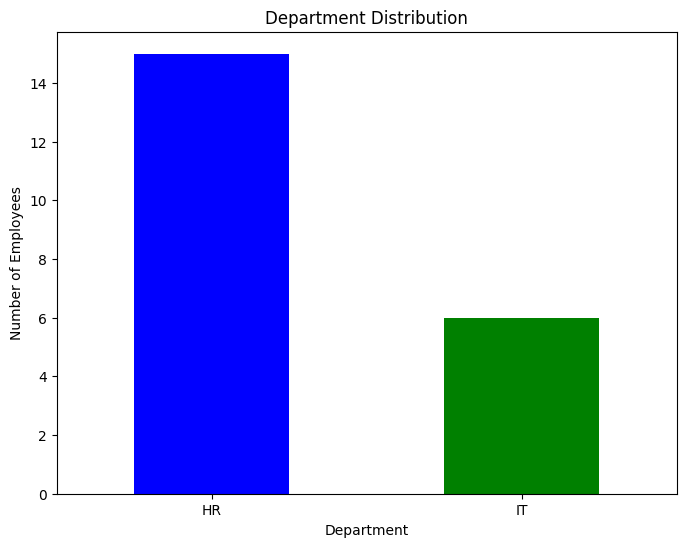

In [17]:
department_counts = df1[['Department_hr', 'Department_it']].sum()

# Plotting department distribution
department_counts.plot(kind='bar', color=['blue', 'green'], figsize=(8, 6))

plt.title("Department Distribution")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(ticks=[0, 1], labels=["HR", "IT"], rotation=0)

plt.show()

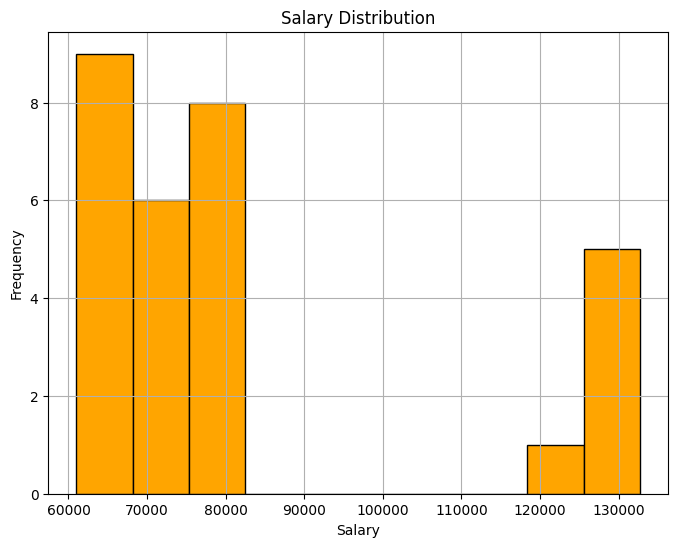

In [18]:
plt.figure(figsize=(8, 6))

plt.hist(df1['Salary'], bins=10, color='orange', edgecolor='black')

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")

plt.grid(True)
plt.show()

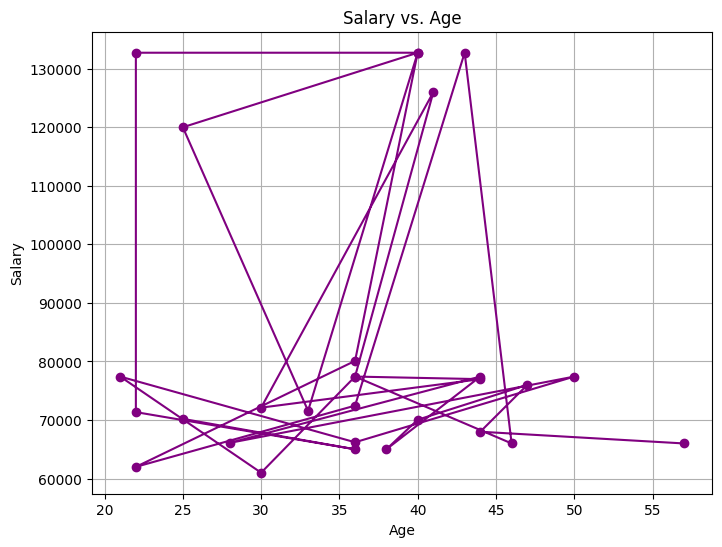

In [19]:
plt.figure(figsize=(8, 6))

plt.plot(df1['Age'], df1['Salary'], marker='o', linestyle='-', color='purple')

plt.title("Salary vs. Age")
plt.xlabel("Age")
plt.ylabel("Salary")

plt.grid(True)
plt.show()

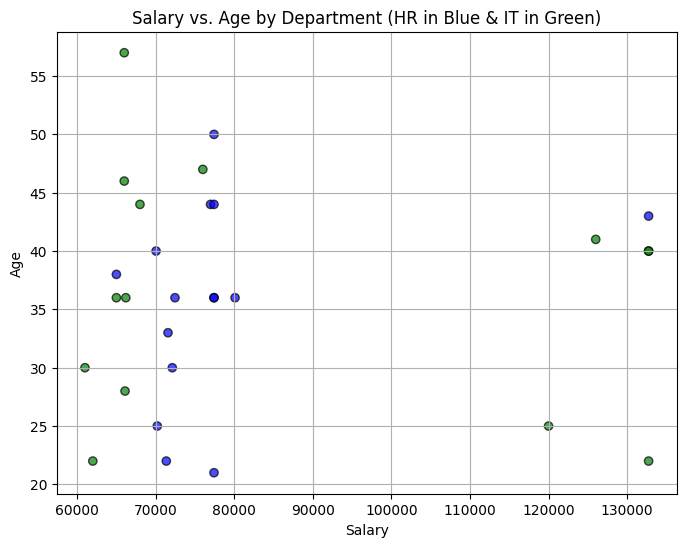

In [20]:
plt.figure(figsize=(8, 6))

colors = ['blue' if dept == 1 else 'green' for dept in df1['Department_hr']]

plt.scatter(
    df1['Salary'],
    df1['Age'],
    c=colors,
    alpha=0.7,
    edgecolor='black'
)

plt.title("Salary vs. Age by Department (HR in Blue & IT in Green)")
plt.xlabel("Salary")
plt.ylabel("Age")

plt.grid(True)
plt.show()